# Packages

In [25]:
import pandas as pd
import numpy as np 
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
import os

from matplotlib import rcParams

rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs

# Data

In [27]:
# setting up addresses

# proj_folder   = Path("/home/janzules/spatial/CAR-T/data/cell2location") # Gemini
proj_folder  = Path("/Users/janzules/Roselab/Spatial/CAR_T/data/cell2location/")

out_figs = proj_folder / "figures/manual_qc"

# Files
adata_file = proj_folder / "cell2location_map/sp_200_epochs.h5ad"



In [19]:
# Load data
adata_vis = sc.read_h5ad(adata_file)

In [20]:
adata_vis

AnnData object with n_obs × n_vars = 427296 × 12128
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', 'treatment', 'batch_core', 'mt_counts', '_indices', '_scvi_batch', '_scvi_labels', 'total RNA counts'
    var: 'SYMBOL'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'mod', 'spatialdata_attrs'
    obsm: 'means_cell_abundance_w_sf', 'q05_cell_abundance_w_sf', 'q50_cell_abundance_w_sf', 'q95_cell_abundance_w_sf', 'spatial', 'stds_cell_abundance_w_sf'

# QC plots

In [13]:
adata_vis.obsm['spatial']

array([[2243.10627289, 3877.96541023],
       [3007.45708502, 1910.70748988],
       [1196.6688773 , 2384.42431694],
       ...,
       [6390.63778089, 6722.43893764],
       [6425.88500703, 6550.06110843],
       [6314.0503469 , 6782.51023321]], shape=(427296, 2))

In [21]:
# Sanity checks: required outputs exist
required_obsm = [
    "means_cell_abundance_w_sf",
    "q05_cell_abundance_w_sf",
    "q95_cell_abundance_w_sf",
    "spatial",
]
missing = [k for k in required_obsm if k not in adata_vis.obsm_keys()]
print("Missing obsm keys:", missing)

print("adata_vis shape:", adata_vis.shape)
print("TMA levels:", adata_vis.obs["TMA"].astype(str).unique().tolist())
print("spatial coords shape:", adata_vis.obsm["spatial"].shape)

# Helpful aliases
coords = adata_vis.obsm["spatial"]
tmа = adata_vis.obs["TMA"].astype(str).values

Missing obsm keys: []
adata_vis shape: (427296, 12128)
TMA levels: ['F07839', 'F07840', 'F08542', 'F08543']
spatial coords shape: (427296, 2)


/var/folders/np/h5smkry919g1mwf1wtltfqtm0000gp/T/ipykernel_2013/108366183.py:8: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  missing = [k for k in required_obsm if k not in adata_vis.obsm_keys()]


In [22]:
import numpy as np

means = adata_vis.obsm["means_cell_abundance_w_sf"]
q05   = adata_vis.obsm["q05_cell_abundance_w_sf"]
q95   = adata_vis.obsm["q95_cell_abundance_w_sf"]

# Convert to numpy arrays if they aren't already (they usually are)
means = np.asarray(means)
q05 = np.asarray(q05)
q95 = np.asarray(q95)

# Winner / ambiguity on means
winner_idx = means.argmax(axis=1)
winner_mean = means[np.arange(means.shape[0]), winner_idx]

# Top2 margin (means)
# partial sort to avoid full sort cost
top2 = np.partition(means, -2, axis=1)[:, -2:]      # (n, 2) unsorted
top2_sorted = np.sort(top2, axis=1)                 # ascending
margin_top1_top2 = top2_sorted[:, 1] - top2_sorted[:, 0]

# Conservative confidence: q05 of the winning type
winner_q05 = q05[np.arange(q05.shape[0]), winner_idx]

# Uncertainty width: q95 - q05 for the winning type
winner_q95 = q95[np.arange(q95.shape[0]), winner_idx]
winner_iqr90 = winner_q95 - winner_q05  # 90% interval width for the winner

# Total inferred abundance per cell (mean + q05)
total_abundance_mean = means.sum(axis=1)
total_abundance_q05  = q05.sum(axis=1)

# Observed total counts (you have this in obs)
total_counts = adata_vis.obs["total RNA counts"].to_numpy()

print("Computed metrics:")
print(" winner_mean:", winner_mean.min(), winner_mean.max())
print(" margin_top1_top2:", margin_top1_top2.min(), margin_top1_top2.max())
print(" winner_q05:", winner_q05.min(), winner_q05.max())
print(" total_abundance_mean:", total_abundance_mean.min(), total_abundance_mean.max())
print(" total_counts:", total_counts.min(), total_counts.max())


Computed metrics:
 winner_mean: 0.04098334 1.3036332
 margin_top1_top2: 4.4703484e-08 0.99390566
 winner_q05: 0.018739196 0.95990837
 total_abundance_mean: 0.4275857 6.917683
 total_counts: 4.0 45900.0


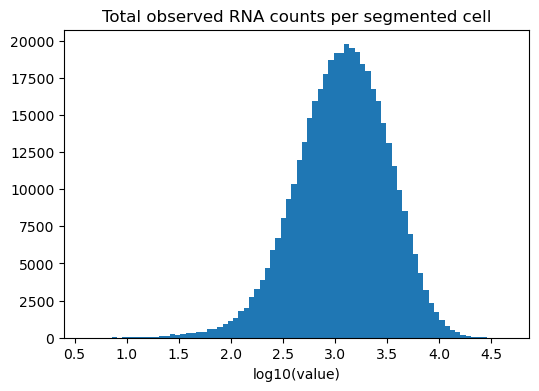

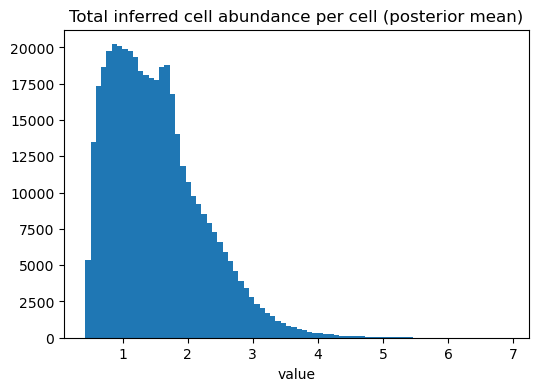

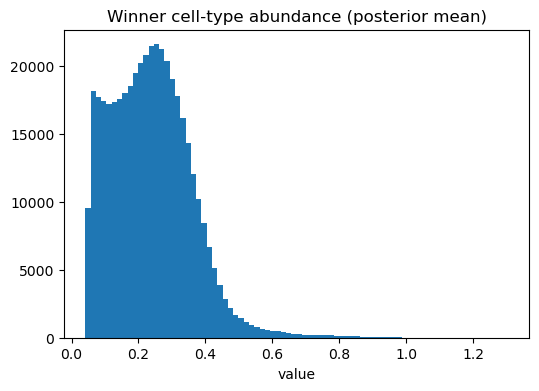

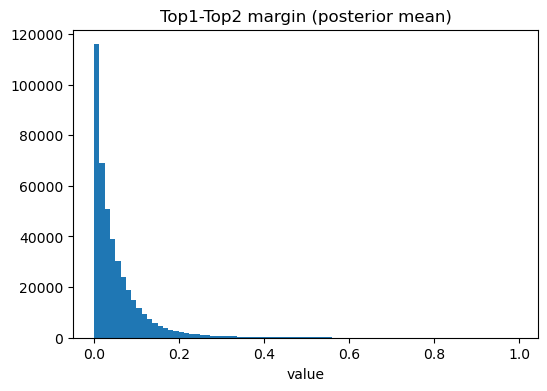

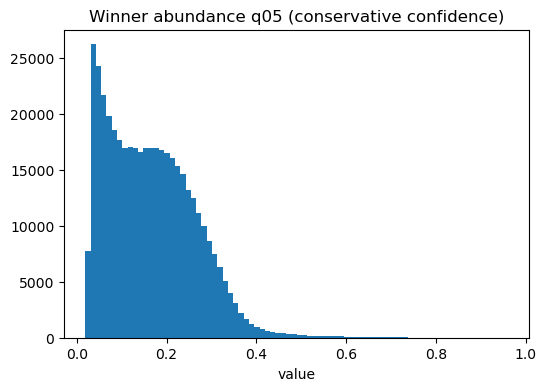

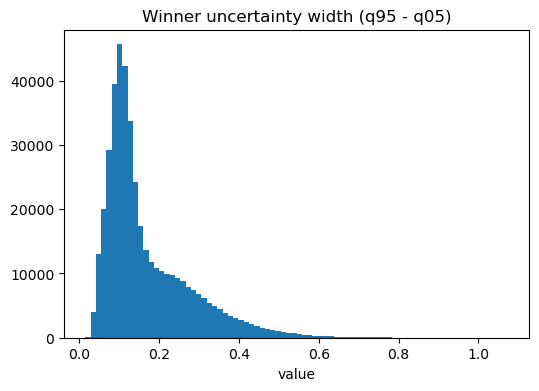

In [30]:
def hist1(x, title, bins=60, log=False, save=True, out_name="name"):
    x = np.asarray(x)
    fig, ax = plt.subplots(figsize=(6,4))
    if log:
        x = x[x > 0]
        ax.hist(np.log10(x), bins=bins)
        ax.set_xlabel("log10(value)")
    else:
        ax.hist(x, bins=bins)
        ax.set_xlabel("value")
    ax.set_title(title)
    if save == True:
        if out_name == "name":
            raise ValueError("Give name to plot")
        outfig = out_figs / out_name
        plt.savefig(outfig, dpi=200, bbox_inches="tight")
            
    plt.show()

    

hist1(total_counts, "Total observed RNA counts per segmented cell", bins=80, log=True, save=True, out_name = "Total_RNA")
hist1(total_abundance_mean, "Total inferred cell abundance per cell (posterior mean)", bins=80, log=False, save=True, out_name = "Inferred_abundance")
hist1(winner_mean, "Winner cell-type abundance (posterior mean)", bins=80, log=False, save=True, out_name = "Winner_abundance")
hist1(margin_top1_top2, "Top1-Top2 margin (posterior mean)", bins=80, log=False, save=True, out_name = "Top1_2_margin")
hist1(winner_q05, "Winner abundance q05 (conservative confidence)", bins=80, log=False, save=True, out_name = "Winner_Abundance_q05")
hist1(winner_iqr90, "Winner uncertainty width (q95 - q05)", bins=80, log=False, save=True, out_name = "Winner_uncertainty(q95-05)")


# Annotating

In [32]:
# Extract matrices

means = adata_vis.obsm["means_cell_abundance_w_sf"]
q05   = adata_vis.obsm["q05_cell_abundance_w_sf"]

celltypes = means.columns.tolist()

In [33]:
# Compute margins
means_np = means.values

top1_idx = means_np.argmax(axis=1)
top1_val = means_np[np.arange(means_np.shape[0]), top1_idx]

# top2
means_sorted = np.sort(means_np, axis=1)
top2_val = means_sorted[:, -2]

margin = top1_val - top2_val

winner_labels = np.array(celltypes)[top1_idx]


In [34]:
# extract q05 for winning type
q05_np = q05.values
winner_q05 = q05_np[np.arange(q05_np.shape[0]), top1_idx]


In [35]:
# Assign confidence tiers
confidence = np.full(adata_vis.n_obs, "unknown", dtype=object)

# High confidence
high_mask = (winner_q05 >= 0.20) & (margin >= 0.05)
confidence[high_mask] = "high"

# Moderate confidence (permissive)
moderate_mask = (
    (confidence == "unknown") &
    (top1_val >= 0.25) &
    (margin >= 0.02)
)
confidence[moderate_mask] = "moderate"

# Weak (exploratory only)
weak_mask = (
    (confidence == "unknown") &
    (top1_val >= 0.20)
)
confidence[weak_mask] = "weak"


In [40]:
# Write labels to obs
adata_vis.obs["c2l_winner"] = winner_labels
adata_vis.obs["c2l_confidence_tier"] = confidence

adata_vis.obs["c2l_label_strict"] = np.where(
    confidence == "high",
    winner_labels,
    "Unknown"
)

adata_vis.obs["c2l_label_permissive"] = np.where(
    np.isin(confidence, ["high", "moderate"]),
    winner_labels,
    "Unknown"
)


In [41]:
# SC - value counts
adata_vis.obs["c2l_confidence_tier"].value_counts()


c2l_confidence_tier
unknown     172545
weak        100330
high         85255
moderate     69166
Name: count, dtype: int64

In [43]:
pd.crosstab(
    adata_vis.obs["c2l_label_permissive"],
    adata_vis.obs["treatment"]
)


treatment,CyPSCA_Tu1,CyPSCA_Tu2,CyTAG72_Tu1,CyTAG72_Tu2,NoTx_Tu1,NoTx_Tu2,RTCyPSCA_Tu1,RTCyPSCA_Tu2,RTCyTAG72_Tu1,RTCyTAG72_Tu2
c2l_label_permissive,,,,,,,,,,
Unknown,45849,7733,24603,5967,3151,66869,26566,23430,659,68048
meanscell_abundance_w_sf_B/T_cell,11,4,2,1,0,12,8,21,0,23
meanscell_abundance_w_sf_B_cell,67,9,24,8,0,66,24,36,3,82
meanscell_abundance_w_sf_CAR_T_cell,6009,1586,535,904,639,3527,2524,4579,179,3159
meanscell_abundance_w_sf_DC,8,1,8,3,0,0,7,7,0,11
meanscell_abundance_w_sf_Endothelial,429,231,413,872,329,409,650,601,78,1094
meanscell_abundance_w_sf_Erythrocyte,1843,1536,3661,5537,486,330,5104,4482,1152,6387
meanscell_abundance_w_sf_Fibroblast,3586,623,69,1520,9030,16256,3617,5047,65,1535
meanscell_abundance_w_sf_Macrophage,210,181,1282,1368,2,17,897,1158,173,2332


In [45]:
adata_vis.obs["c2l_confidence_tier"].value_counts()


c2l_confidence_tier
unknown     172545
weak        100330
high         85255
moderate     69166
Name: count, dtype: int64

In [46]:
import re
import numpy as np

def strip_c2l_prefix(x: str) -> str:
    # remove common prefixes you might have
    x = re.sub(r"^means_cell_abundance_w_sf_", "", x)
    x = re.sub(r"^meanscell_abundance_w_sf_", "", x)
    x = re.sub(r"^q05_cell_abundance_w_sf_", "", x)
    x = re.sub(r"^q50_cell_abundance_w_sf_", "", x)
    return x

adata_vis.obs["c2l_winner_clean"] = adata_vis.obs["c2l_winner"].astype(str).map(strip_c2l_prefix)
adata_vis.obs["c2l_label_strict_clean"] = adata_vis.obs["c2l_label_strict"].astype(str).map(strip_c2l_prefix)
adata_vis.obs["c2l_label_perm_clean"] = adata_vis.obs["c2l_label_permissive"].astype(str).map(strip_c2l_prefix)


In [49]:
adata_vis.obs["c2l_label_perm_clean"].value_counts()


c2l_label_perm_clean
Unknown        272875
Fibroblast      41348
Erythrocyte     30518
CAR_T_cell      23641
Neutrophils     19860
NK_cell         18779
Macrophage       7620
Monocyte         6744
Endothelial      5106
T_cell            359
B_cell            319
B/T_cell           82
DC                 45
Name: count, dtype: int64

In [59]:
pd.crosstab(
    adata_vis.obs["c2l_label_strict_clean"],
    adata_vis.obs["treatment"]
)


treatment,CyPSCA_Tu1,CyPSCA_Tu2,CyTAG72_Tu1,CyTAG72_Tu2,NoTx_Tu1,NoTx_Tu2,RTCyPSCA_Tu1,RTCyPSCA_Tu2,RTCyTAG72_Tu1,RTCyTAG72_Tu2
c2l_label_strict_clean,,,,,,,,,,
B/T_cell,2,0,1,0,0,1,0,2,0,2
B_cell,7,1,5,2,0,8,4,5,0,21
CAR_T_cell,922,221,141,262,230,545,829,1122,77,663
DC,3,0,5,2,0,0,2,3,0,8
Endothelial,249,145,342,563,207,313,350,323,31,847
Erythrocyte,794,891,2801,4232,311,95,2866,2709,914,3247
Fibroblast,1892,259,34,888,7070,10570,1977,2707,18,889
Macrophage,144,87,1105,1087,1,13,581,756,96,2018
Monocyte,1814,414,101,81,0,1,802,1074,16,252


# Proportion numbers

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEFAULT_IMMUNE_LABELS = [
    "B/T_cell", "B_cell", "CAR_T_cell", "DC",
    "Macrophage", "Monocyte", "NK_cell", "Neutrophils", "T_cell"
]

def c2l_fraction_within_immune(
    adata,
    label_col: str,
    group_cols,
    target_label: str,
    immune_labels=None,
    drop_unknown: bool = True,
):
    """
    Fraction of target immune label among ALL immune cells in each group.

    fraction = count(target_label) / sum(count(immune_labels))

    Parameters
    ----------
    adata : AnnData
    label_col : e.g. "c2l_label_strict_clean" or "c2l_label_perm_clean"
    group_cols : str or list[str], e.g. "treatment" or ["TMA","treatment"]
    target_label : e.g. "CAR_T_cell" or "Neutrophils"
    immune_labels : list of labels considered immune (default DEFAULT_IMMUNE_LABELS)
    drop_unknown : if True, remove "Unknown" before filtering immune labels
    """
    if isinstance(group_cols, str):
        group_cols = [group_cols]
    if immune_labels is None:
        immune_labels = DEFAULT_IMMUNE_LABELS

    # Minimal df
    df = adata.obs[group_cols + [label_col]].copy()
    df[label_col] = df[label_col].astype(str)

    if drop_unknown:
        df = df[df[label_col] != "Unknown"].copy()

    # keep immune only
    df = df[df[label_col].isin(immune_labels)].copy()

    # counts per group per label
    counts = (
        df.groupby(group_cols + [label_col], observed=True)
          .size()
          .rename("n")
          .reset_index()
    )

    # pivot to wide
    wide = counts.pivot_table(
        index=group_cols,
        columns=label_col,
        values="n",
        fill_value=0,
        aggfunc="sum",
        observed=True,   # avoids that pandas warning
    )

    # ensure all immune labels exist
    for lab in immune_labels:
        if lab not in wide.columns:
            wide[lab] = 0

    # compute numerator + denominator
    if target_label not in wide.columns:
        wide[target_label] = 0

    numerator = wide[target_label].astype(float)
    denom = wide[immune_labels].sum(axis=1).astype(float)

    frac = np.divide(numerator, denom, out=np.full_like(numerator, np.nan), where=(denom > 0))

    out = wide.copy()
    out[f"{target_label}_count"] = numerator
    out["immune_total_count"] = denom
    out[f"{target_label}_fraction_of_immune"] = frac

    return out.reset_index()


In [66]:
res_neut_strict = c2l_fraction_within_immune(
    adata_vis,
    label_col="c2l_label_strict_clean",
    group_cols="treatment",
    target_label="Neutrophils",
)

res_neut_strict[["treatment", "Neutrophils_count", "immune_total_count", "Neutrophils_fraction_of_immune"]].sort_values(
    "Neutrophils_fraction_of_immune", ascending=False
)


c2l_label_strict_clean,treatment,Neutrophils_count,immune_total_count,Neutrophils_fraction_of_immune
8,RTCyTAG72_Tu1,253.0,442.0,0.572398
6,RTCyPSCA_Tu1,2763.0,5058.0,0.546263
7,RTCyPSCA_Tu2,2739.0,6510.0,0.420737
4,NoTx_Tu1,316.0,891.0,0.354658
3,CyTAG72_Tu2,731.0,2260.0,0.323451
1,CyPSCA_Tu2,580.0,2312.0,0.250865
5,NoTx_Tu2,982.0,5517.0,0.177995
0,CyPSCA_Tu1,1252.0,7345.0,0.170456
2,CyTAG72_Tu1,212.0,1709.0,0.124049
9,RTCyTAG72_Tu2,501.0,4677.0,0.107120


In [81]:
res_neut_strict = c2l_fraction_within_immune(
    adata_vis,
    label_col="c2l_label_strict_clean",
    group_cols="treatment",
    target_label="NK_cell",
)

res_neut_strict[['treatment', 'NK_cell_count', 'immune_total_count', 'NK_cell_fraction_of_immune']].sort_values(
    "NK_cell_fraction_of_immune", ascending=False
)


c2l_label_strict_clean,treatment,NK_cell_count,immune_total_count,NK_cell_fraction_of_immune
5,NoTx_Tu2,3953.0,5517.0,0.716513
1,CyPSCA_Tu2,1009.0,2312.0,0.436419
0,CyPSCA_Tu1,3174.0,7345.0,0.432131
4,NoTx_Tu1,344.0,891.0,0.386083
9,RTCyTAG72_Tu2,1206.0,4677.0,0.257858
7,RTCyPSCA_Tu2,800.0,6510.0,0.122888
2,CyTAG72_Tu1,139.0,1709.0,0.081334
3,CyTAG72_Tu2,95.0,2260.0,0.042035
6,RTCyPSCA_Tu1,76.0,5058.0,0.015026
8,RTCyTAG72_Tu1,0.0,442.0,0.000000


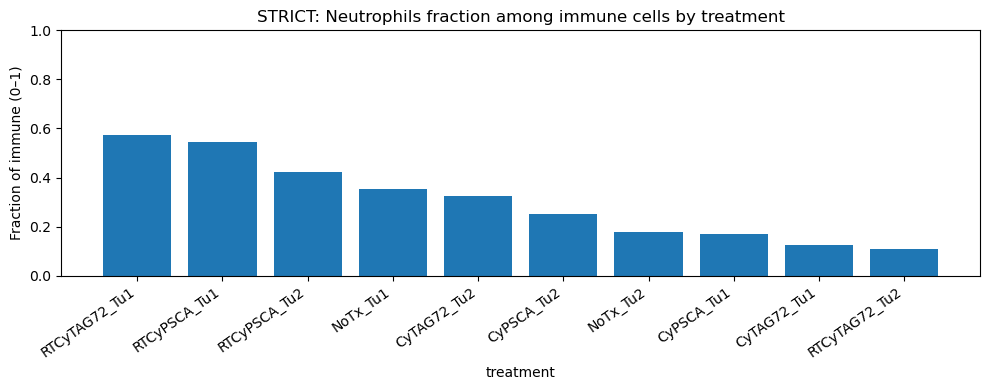

In [67]:
def plot_fraction_bar(df, group_col, frac_col, title=None, sort=True):
    d = df[[group_col, frac_col]].dropna().copy()
    if sort:
        d = d.sort_values(frac_col, ascending=False)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(d[group_col].astype(str), d[frac_col].to_numpy())
    ax.set_ylabel("Fraction of immune (0–1)")
    ax.set_xlabel(group_col)
    ax.set_title(title if title else frac_col)
    ax.set_ylim(0, 1)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

plot_fraction_bar(
    res_neut_strict,
    group_col="treatment",
    frac_col="Neutrophils_fraction_of_immune",
    title="STRICT: Neutrophils fraction among immune cells by treatment"
)


## table

In [82]:
import pandas as pd

DEFAULT_IMMUNE_LABELS = [
    "B/T_cell", "B_cell", "CAR_T_cell", "DC",
    "Macrophage", "Monocyte", "NK_cell", "Neutrophils", "T_cell"
]

def immune_fraction_table(
    adata,
    label_col: str,
    group_col: str = "treatment",
    immune_labels=None,
    drop_unknown: bool = True,
):
    """
    Return a table like pd.crosstab(label, group) but values are
    fractions within immune per group (columns sum to 1).

    Excludes non-immune by restricting to immune_labels.
    """
    if immune_labels is None:
        immune_labels = DEFAULT_IMMUNE_LABELS

    df = adata.obs[[label_col, group_col]].copy()
    df[label_col] = df[label_col].astype(str)

    if drop_unknown:
        df = df[df[label_col] != "Unknown"].copy()

    # keep immune only
    df = df[df[label_col].isin(immune_labels)].copy()

    # counts table
    ct = pd.crosstab(df[label_col], df[group_col])

    # ensure all immune rows exist (even if 0)
    ct = ct.reindex(immune_labels, fill_value=0)

    # convert to fractions within each column
    frac = ct.div(ct.sum(axis=0), axis=1)

    return frac, ct


In [83]:
frac_strict, counts_strict = immune_fraction_table(
    adata_vis,
    label_col="c2l_label_strict_clean",
    group_col="treatment",
)

frac_strict


treatment,CyPSCA_Tu1,CyPSCA_Tu2,CyTAG72_Tu1,CyTAG72_Tu2,NoTx_Tu1,NoTx_Tu2,RTCyPSCA_Tu1,RTCyPSCA_Tu2,RTCyTAG72_Tu1,RTCyTAG72_Tu2
c2l_label_strict_clean,,,,,,,,,,
B/T_cell,0.000272,0.000000,0.000585,0.000000,0.000000,0.000181,0.000000,0.000307,0.000000,0.000428
B_cell,0.000953,0.000433,0.002926,0.000885,0.000000,0.001450,0.000791,0.000768,0.000000,0.004490
CAR_T_cell,0.125528,0.095588,0.082504,0.115929,0.258137,0.098786,0.163899,0.172350,0.174208,0.141758
DC,0.000408,0.000000,0.002926,0.000885,0.000000,0.000000,0.000395,0.000461,0.000000,0.001710
Macrophage,0.019605,0.037630,0.646577,0.480973,0.001122,0.002356,0.114868,0.116129,0.217195,0.431473
Monocyte,0.246971,0.179066,0.059099,0.035841,0.000000,0.000181,0.158561,0.164977,0.036199,0.053881
NK_cell,0.432131,0.436419,0.081334,0.042035,0.386083,0.716513,0.015026,0.122888,0.000000,0.257858
Neutrophils,0.170456,0.250865,0.124049,0.323451,0.354658,0.177995,0.546263,0.420737,0.572398,0.107120
T_cell,0.003676,0.000000,0.000000,0.000000,0.000000,0.002538,0.000198,0.001382,0.000000,0.001283


In [84]:
import matplotlib.pyplot as plt
import numpy as np

def plot_immune_fraction_heatmap(
    frac_df,
    as_percent=True,
    cmap="viridis",
    figsize=(12, 6),
    vmin=0,
    vmax=None,
):
    """
    frac_df: DataFrame (rows = immune cell types, columns = conditions)
    """
    data = frac_df.copy()

    if as_percent:
        data = data * 100
        label = "Fraction of immune cells (%)"
    else:
        label = "Fraction of immune cells"

    if vmax is None:
        vmax = data.values.max()

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        data.values,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_yticks(np.arange(data.shape[0]))

    ax.set_xticklabels(data.columns, rotation=45, ha="right")
    ax.set_yticklabels(data.index)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(label)

    ax.set_title("Immune cell composition by treatment")

    plt.tight_layout()
    plt.show()


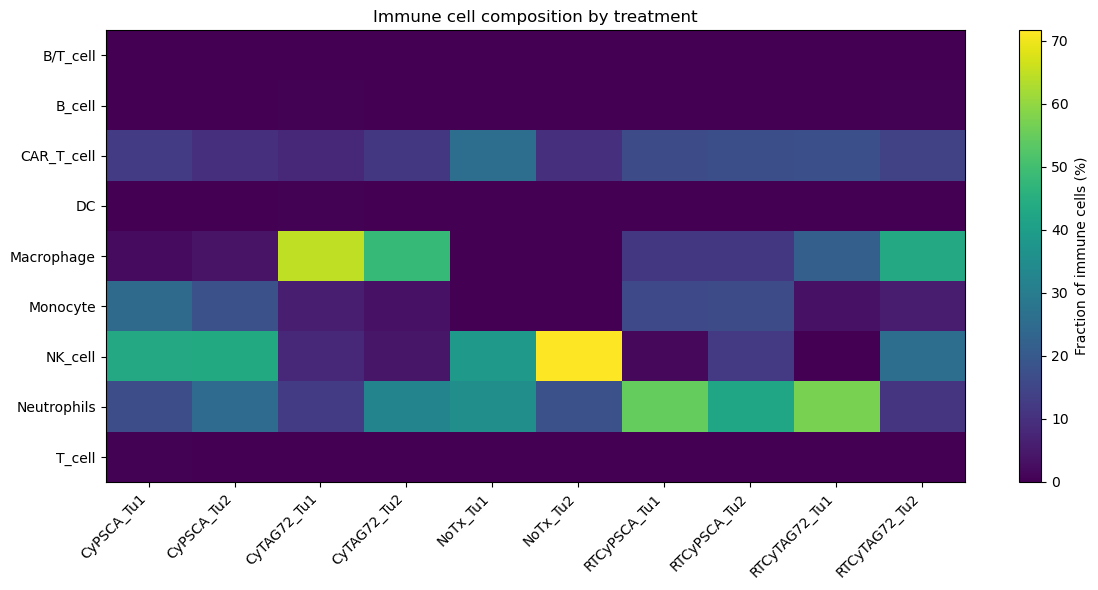

In [85]:
plot_immune_fraction_heatmap(frac_strict, as_percent=True)


# Visualizing

Plotting 3477 cells


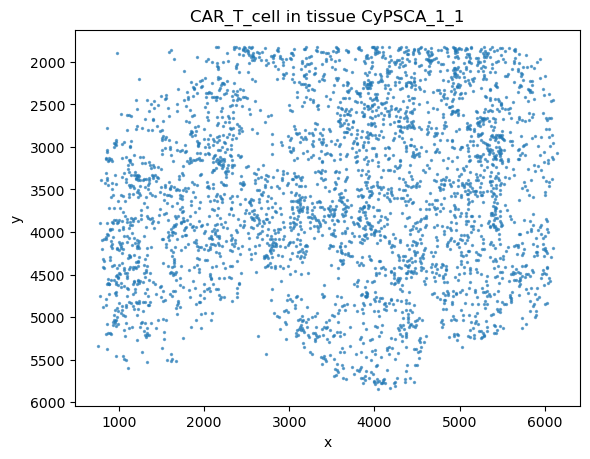

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# USER CHOICES
# -----------------------------
tissue_of_interest = "CyPSCA_1_1"   # <-- change this
cell_type = "CAR_T_cell"           # <-- change this

# -----------------------------
# SUBSET
# -----------------------------
mask = (
    (adata_vis.obs["tissue"] == tissue_of_interest) &
    (adata_vis.obs["c2l_label_perm_clean"] == cell_type)
)

coords = adata_vis.obsm["spatial"][mask]

print(f"Plotting {coords.shape[0]} cells")

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(
    coords[:, 0],
    coords[:, 1],
    s=2,
    alpha=0.6
)

ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_title(f"{cell_type} in tissue {tissue_of_interest}")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.tight_layout()
plt.show()


# Processing Output

In [10]:
adata_vis.obsm.keys()

KeysView(AxisArrays with keys: means_cell_abundance_w_sf, q05_cell_abundance_w_sf, q50_cell_abundance_w_sf, q95_cell_abundance_w_sf, spatial, stds_cell_abundance_w_sf)

In [11]:
adata_vis.obsm['q50_cell_abundance_w_sf'].head()

,q50cell_abundance_w_sf_B/T_cell,q50cell_abundance_w_sf_B_cell,q50cell_abundance_w_sf_CAR_T_cell,q50cell_abundance_w_sf_DC,q50cell_abundance_w_sf_Endothelial,q50cell_abundance_w_sf_Erythrocyte,q50cell_abundance_w_sf_Fibroblast,q50cell_abundance_w_sf_Macrophage,q50cell_abundance_w_sf_Monocyte,q50cell_abundance_w_sf_NK_cell,q50cell_abundance_w_sf_Neutrophils,q50cell_abundance_w_sf_T_cell
F07839_cellid_000000001-1,0.139362,0.178377,0.306196,0.149224,0.126733,0.110238,0.165652,0.192729,0.132538,0.241612,0.100723,0.179276
F07839_cellid_000000002-1,0.170081,0.152123,0.148032,0.118927,0.121380,0.108779,0.137355,0.080164,0.098760,0.332116,0.081493,0.305034
F07839_cellid_000000004-1,0.054743,0.063804,0.102851,0.093381,0.120290,0.406426,0.109943,0.111466,0.176827,0.049009,0.092760,0.052604
F07839_cellid_000000005-1,0.090580,0.143149,0.108105,0.134819,0.090431,0.078364,0.042432,0.079130,0.290191,0.298292,0.144948,0.187113
F07839_cellid_000000006-1,0.136322,0.140619,0.121414,0.173427,0.121563,0.074453,0.113175,0.062200,0.225761,0.149344,0.147762,0.134722


# Looking c2l output

In [14]:
import numpy as np
import pandas as pd

def clean_cols(df):
    df = df.copy()
    df.columns = [c.split("w_sf_")[-1] for c in df.columns]
    return df

w = clean_cols(adata_vis.obsm["means_cell_abundance_w_sf"])
total = w.sum(axis=1)
total.describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99])


count    427296.000000
mean          1.398394
std           0.478674
min           0.805028
1%            0.854612
5%            0.873224
10%           0.895015
25%           0.996874
50%           1.304518
75%           1.610943
90%           2.185626
95%           2.442166
99%           2.678682
max           2.954294
dtype: float64

In [15]:
vals = np.sort(w.to_numpy(), axis=1)
margin = vals[:, -1] - vals[:, -2]
pd.Series(margin).describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99])


count    4.272960e+05
mean     2.388054e-02
std      2.712289e-02
min      2.980232e-08
1%       7.615238e-05
5%       3.995001e-04
10%      8.637607e-04
25%      2.834691e-03
50%      1.291791e-02
75%      3.697268e-02
90%      6.451277e-02
95%      8.246324e-02
99%      1.097034e-01
max      1.840407e-01
dtype: float64

In [16]:
w05 = clean_cols(adata_vis.obsm["q05_cell_abundance_w_sf"])
winner = w.idxmax(axis=1).to_numpy()
idx = pd.Index(w05.columns).get_indexer(winner)
rows = np.arange(adata_vis.n_obs)
q05_winner = w05.to_numpy()[rows, idx]
pd.Series(q05_winner).describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99])


count    427296.000000
mean          0.133662
std           0.045443
min           0.051029
1%            0.058087
5%            0.061265
10%           0.063741
25%           0.082679
50%           0.152737
75%           0.171280
90%           0.180597
95%           0.186048
99%           0.197733
max           0.227127
dtype: float64

# Generating figures

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def clean_cols(df):
    df = df.copy()
    df.columns = [c.split("w_sf_")[-1] for c in df.columns]
    return df

w_mean = clean_cols(adata_vis.obsm["means_cell_abundance_w_sf"])
w05    = clean_cols(adata_vis.obsm["q05_cell_abundance_w_sf"])
w95    = clean_cols(adata_vis.obsm["q95_cell_abundance_w_sf"])

# total inferred abundance per cell
total = w_mean.sum(axis=1)

# argmax label + top score (mean)
label = w_mean.idxmax(axis=1)
score = w_mean.max(axis=1)

# dominance / ambiguity: top1 - top2
vals = np.sort(w_mean.to_numpy(), axis=1)
margin = vals[:, -1] - vals[:, -2]

# conservative confidence: q05 of the winning label
idx = pd.Index(w05.columns).get_indexer(label.to_numpy())
rows = np.arange(adata_vis.n_obs)
q05_winner = w05.to_numpy()[rows, idx]

# store in obs for later plotting
adata_vis.obs["c2l_total_mean"] = total.to_numpy()
adata_vis.obs["c2l_label_mean"] = label.astype(str).to_numpy()
adata_vis.obs["c2l_score_mean"] = score.to_numpy()
adata_vis.obs["c2l_margin_mean"] = margin
adata_vis.obs["c2l_q05_winner"] = q05_winner

adata_vis.obs[["c2l_total_mean","c2l_score_mean","c2l_margin_mean","c2l_q05_winner"]].describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99])


,c2l_total_mean,c2l_score_mean,c2l_margin_mean,c2l_q05_winner
count,427296.000000,427296.000000,4.272960e+05,427296.000000
mean,1.398394,0.162946,2.388054e-02,0.133662
std,0.478674,0.053183,2.712289e-02,0.045443
min,0.805028,0.069479,2.980232e-08,0.051029
1%,0.854612,0.074644,7.615238e-05,0.058087
5%,0.873224,0.077166,3.995001e-04,0.061265
10%,0.895015,0.079906,8.637607e-04,0.063741
25%,0.996874,0.103470,2.834691e-03,0.082679
50%,1.304518,0.186555,1.291791e-02,0.152737
75%,1.610943,0.206360,3.697268e-02,0.171280


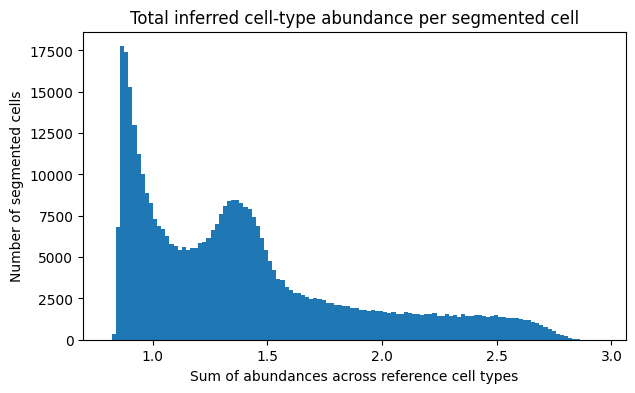

In [18]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(adata_vis.obs["c2l_total_mean"], bins=120)
ax.set_title("Total inferred cell-type abundance per segmented cell")
ax.set_xlabel("Sum of abundances across reference cell types")
ax.set_ylabel("Number of segmented cells")
plt.show()


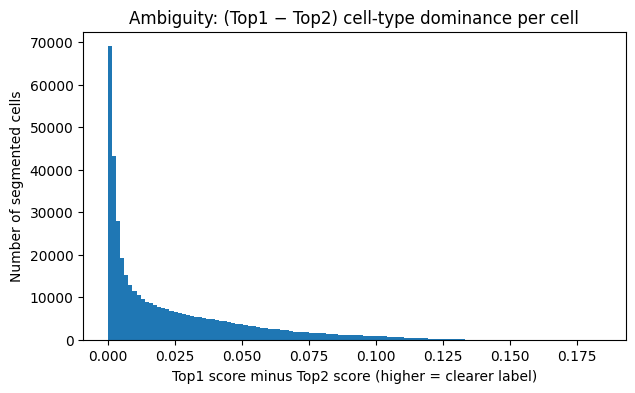

In [20]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(adata_vis.obs["c2l_margin_mean"], bins=120)
ax.set_title("Ambiguity: (Top1 − Top2) cell-type dominance per cell")
ax.set_xlabel("Top1 score minus Top2 score (higher = clearer label)")
ax.set_ylabel("Number of segmented cells")
plt.show()


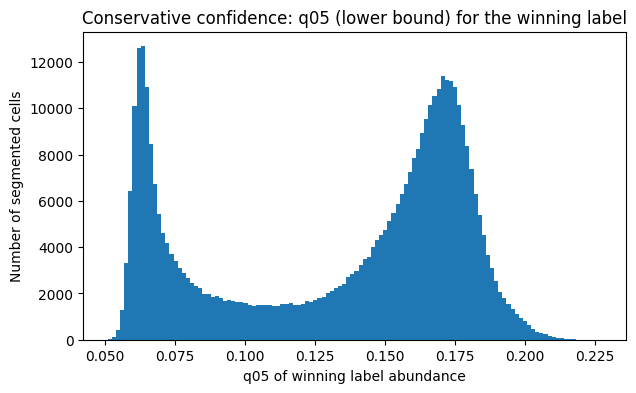

In [21]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(adata_vis.obs["c2l_q05_winner"], bins=120)
ax.set_title("Conservative confidence: q05 (lower bound) for the winning label")
ax.set_xlabel("q05 of winning label abundance")
ax.set_ylabel("Number of segmented cells")
plt.show()


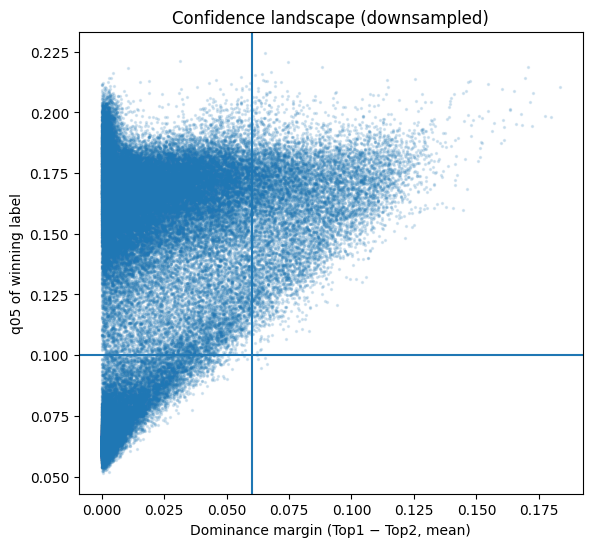

In [22]:
# downsample for scatter
n = adata_vis.n_obs
rng = np.random.default_rng(0)
take = rng.choice(n, size=min(n, 80_000), replace=False)

x = adata_vis.obs["c2l_margin_mean"].to_numpy()[take]
y = adata_vis.obs["c2l_q05_winner"].to_numpy()[take]

# choose example strict cutoffs (tune these)
m_cut = 0.06
q_cut = 0.10

fig, ax = plt.subplots(figsize=(6.5,6))
ax.scatter(x, y, s=2, alpha=0.15)
ax.axvline(m_cut)
ax.axhline(q_cut)
ax.set_title("Confidence landscape (downsampled)")
ax.set_xlabel("Dominance margin (Top1 − Top2, mean)")
ax.set_ylabel("q05 of winning label")
plt.show()


In [23]:
m_cut = 0.06
q_cut = 0.10

conf = (adata_vis.obs["c2l_margin_mean"] >= m_cut) & (adata_vis.obs["c2l_q05_winner"] >= q_cut)

adata_vis.obs["c2l_label_strict"] = "Unassigned"
adata_vis.obs.loc[conf, "c2l_label_strict"] = adata_vis.obs.loc[conf, "c2l_label_mean"]

print("Fraction assigned:", conf.mean())
adata_vis.obs["c2l_label_strict"].value_counts().head(20)


Fraction assigned: 0.11745487905339624


c2l_label_strict
Unassigned     377108
Fibroblast      44441
Erythrocyte      2679
Endothelial      1216
Macrophage       1164
NK_cell           515
Neutrophils       116
CAR_T_cell         49
Monocyte            7
T_cell              1
Name: count, dtype: int64

# What's going on with the T cells

In [24]:
w = clean_cols(adata_vis.obsm["means_cell_abundance_w_sf"])
w.idxmax(axis=1).value_counts().head(20)

Fibroblast     219966
Erythrocyte     72007
Neutrophils     42202
CAR_T_cell      22507
Macrophage      20436
Endothelial     12547
Monocyte        12356
NK_cell          9544
B_cell           5853
B/T_cell         4022
T_cell           3975
DC               1881
Name: count, dtype: int64

In [25]:
w = clean_cols(adata_vis.obsm["means_cell_abundance_w_sf"])
w05 = clean_cols(adata_vis.obsm["q05_cell_abundance_w_sf"])

winner = w.idxmax(axis=1)
arr = w.to_numpy()
vals = np.sort(arr, axis=1)
margin = vals[:, -1] - vals[:, -2]

# q05 for winner
idx = pd.Index(w05.columns).get_indexer(winner.to_numpy())
rows = np.arange(adata_vis.n_obs)
q05_winner = w05.to_numpy()[rows, idx]

mask_bt = (winner == "B/T_cell").to_numpy()

print("B/T_cell winner count:", mask_bt.sum())
print("Margin stats for B/T_cell winners:")
print(pd.Series(margin[mask_bt]).describe(percentiles=[.5,.75,.9,.95,.99]))
print("q05_winner stats for B/T_cell winners:")
print(pd.Series(q05_winner[mask_bt]).describe(percentiles=[.5,.75,.9,.95,.99]))

# fraction that would pass your strict cutoffs
m_cut = 0.06
q_cut = 0.10
print("Fraction of B/T_cell winners passing strict:",
      ((margin[mask_bt] >= m_cut) & (q05_winner[mask_bt] >= q_cut)).mean())


B/T_cell winner count: 4022
Margin stats for B/T_cell winners:
count    4.022000e+03
mean     1.854689e-03
std      1.885380e-03
min      8.195639e-08
50%      1.198351e-03
75%      2.685346e-03
90%      4.451351e-03
95%      5.817620e-03
99%      8.384061e-03
max      1.359187e-02
dtype: float64
q05_winner stats for B/T_cell winners:
count    4022.000000
mean        0.159218
std         0.051275
min         0.057057
50%         0.183114
75%         0.192785
90%         0.199507
95%         0.203132
99%         0.208940
max         0.215414
dtype: float64
Fraction of B/T_cell winners passing strict: 0.0


In [26]:
cols = np.array(w.columns)
top2 = np.argpartition(arr, kth=-2, axis=1)[:, -2:]
top2_labels = cols[top2]

# for B/T_cell winners, find the runner-up label
# identify which of the two is the winner vs runner-up
bt_top2 = top2_labels[mask_bt]
bt_vals_top2 = arr[mask_bt][:, top2[mask_bt] ]  # careful indexing might be messy; simpler approach:

# simpler: just take second best label from full sort
second_idx = np.argsort(arr[mask_bt], axis=1)[:, -2]
runner_up = cols[second_idx]
print(pd.Series(runner_up).value_counts().head(10))


Erythrocyte    700
B_cell         663
T_cell         500
Neutrophils    470
CAR_T_cell     450
NK_cell        440
DC             240
Fibroblast     179
Monocyte       157
Endothelial    150
Name: count, dtype: int64
